## Librerias


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)

from ft_engineering import make_pipeline_ml, split_features_target

## Carga del dataset y preparación base

In [56]:
df = pd.read_excel("Base_de_datos.xlsx")

In [57]:
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,2025-01-07 14:40:36,1852560.0,12,32,Empleado,3500000,1000000,128650,95.227787,...,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,2025-01-09 11:18:48,3181080.0,6,34,Empleado,5000000,2000000,441817,95.227787,...,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,2024-12-26 18:52:57,670200.0,5,34,Independiente,5000000,2000000,108632,95.227787,...,0.0,274561.0,274561.0,NaN,2,0,1,NaN,NaN,1
3,9,2024-12-04 14:20:50,506806.8,2,25,Independiente,3000000,900000,199684,95.227787,...,0.0,27564.0,27564.0,NaN,1,0,6,NaN,NaN,1
4,4,2025-04-30 18:41:57,999780.0,10,26,Empleado,2000000,600000,92509,95.227787,...,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1


In [58]:
x_features_raw, y_target = split_features_target(df, target_col="Pago_atiempo")
y_target = y_target.astype(int)

In [59]:
x_features_raw.shape, y_target.shape

((10763, 22), (10763,))

In [60]:
y_target.value_counts(normalize=True)

Pago_atiempo
1    0.952523
0    0.047477
Name: proportion, dtype: float64

In [63]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x_features_raw,
    y_target,
    test_size=0.25,
    stratify=y_target,
    random_state=42,
)

# 1. Instanciar y ajustar el pipeline SOLO con el conjunto de entrenamiento
pipeline_ml = make_pipeline_ml()
pipeline_ml.fit(x_train_raw, y_train)

# 2. Transformar train y test usando el MISMO pipeline ya ajustado
x_train = pipeline_ml.transform(x_train_raw)
x_test = pipeline_ml.transform(x_test_raw)

In [64]:
x_train.shape, y_train.shape

((8072, 33), (8072,))

In [65]:
x_test.shape, y_test.shape

((2691, 33), (2691,))

In [66]:
x_train

,num__capital_prestado,num__plazo_meses,num__edad_cliente,num__salario_cliente,num__total_otros_prestamos,num__cuota_pactada,num__puntaje,num__puntaje_datacredito,num__cant_creditosvigentes,num__huella_consulta,...,cat__tipo_credito_7,cat__tipo_credito_9,cat__tipo_credito_10,cat__tipo_credito_68,cat__tipo_laboral_Empleado,cat__tipo_laboral_Independiente,cat__grupo_edad_cliente_18-30,cat__grupo_edad_cliente_31-45,cat__grupo_edad_cliente_46-60,cat__grupo_edad_cliente_61-80
4668,-0.599478,-0.698778,0.773047,-0.038642,-0.039503,-0.212132,0.247042,0.411616,-0.961191,-0.072250,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8753,-0.586625,-0.094649,-1.501989,-0.040104,-0.036443,-0.624902,0.247042,0.844040,-0.702842,-0.732729,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
9051,-0.779582,-0.698778,-0.743644,-0.042626,-0.042609,-0.476494,0.247042,-0.101258,0.330553,-0.072250,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1569,-0.488263,-0.698778,1.699914,-0.040104,-0.042609,-0.083289,0.247042,0.381447,-1.219540,-0.402489,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3164,0.340090,-0.698778,-0.069559,-0.043256,-0.045599,1.082948,0.247042,0.069700,-0.702842,-0.402489,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4029,0.331212,0.207415,0.857308,-0.035818,-0.032589,-0.146326,0.247042,-0.292329,1.105600,0.588229,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9496,-0.508268,1.113607,-1.249207,-0.045147,-0.049545,-0.777730,0.247042,-0.513569,2.138995,0.257989,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
788,0.723003,-0.094649,1.362871,-0.041365,-0.042609,0.533261,0.247042,1.035111,-0.702842,-0.402489,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8092,-0.478486,0.207415,-1.080686,-0.040104,-0.040296,-0.589879,0.247042,-0.181709,0.588902,0.918468,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [67]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 8072 entries, 4668 to 5351
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   num__capital_prestado            8072 non-null   float64
 1   num__plazo_meses                 8072 non-null   float64
 2   num__edad_cliente                8072 non-null   float64
 3   num__salario_cliente             8072 non-null   float64
 4   num__total_otros_prestamos       8072 non-null   float64
 5   num__cuota_pactada               8072 non-null   float64
 6   num__puntaje                     8072 non-null   float64
 7   num__puntaje_datacredito         8072 non-null   float64
 8   num__cant_creditosvigentes       8072 non-null   float64
 9   num__huella_consulta             8072 non-null   float64
 10  num__saldo_mora                  8072 non-null   float64
 11  num__saldo_total                 8072 non-null   float64
 12  num__saldo_principal             

In [68]:
x_test

,num__capital_prestado,num__plazo_meses,num__edad_cliente,num__salario_cliente,num__total_otros_prestamos,num__cuota_pactada,num__puntaje,num__puntaje_datacredito,num__cant_creditosvigentes,num__huella_consulta,...,cat__tipo_credito_7,cat__tipo_credito_9,cat__tipo_credito_10,cat__tipo_credito_68,cat__tipo_laboral_Empleado,cat__tipo_laboral_Independiente,cat__grupo_edad_cliente_18-30,cat__grupo_edad_cliente_31-45,cat__grupo_edad_cliente_46-60,cat__grupo_edad_cliente_61-80
2544,0.343948,0.207415,1.868435,-0.043485,-0.050208,0.048517,0.247042,0.260771,-0.186144,-0.402489,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7064,0.251644,0.207415,-0.912165,-0.040735,-0.043641,-0.051624,0.247042,-0.211878,1.363949,1.248707,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8694,0.757995,2.019799,-1.333468,-0.042197,-0.049746,-0.288541,0.247042,-0.272217,-0.186144,0.257989,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5589,-0.668368,0.207415,0.857308,-0.042878,-0.049545,-0.777384,0.048806,0.441785,-0.186144,-0.072250,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5649,-0.823064,-0.849810,1.025829,-0.037583,-0.036443,-0.477663,-0.397224,0.361335,0.847251,-0.732729,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8580,1.175346,-0.245682,-1.333468,-0.041471,-0.042934,0.932250,0.012764,-0.081146,0.847251,-0.732729,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5760,-0.490669,-0.547746,0.351744,-0.037583,-0.036443,-0.308827,0.247042,0.492067,0.072205,1.909186,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4166,-0.407217,-0.698778,-0.069559,-0.042626,-0.051857,0.026242,0.247042,0.401560,-1.219540,-0.402489,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5504,-0.650936,-0.698778,0.183223,-0.035062,-0.040296,-0.303140,0.247042,-0.201822,-0.444493,0.257989,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [69]:
y_test

2544    1
7064    1
8694    1
5589    1
5649    1
       ..
8580    1
5760    1
4166    1
5504    1
1919    1
Name: Pago_atiempo, Length: 2691, dtype: int64

In [70]:
class HeuristicModel(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        puntaje_threshold=-0.4,
        deuda_ingreso_threshold=0.7,
        carga_pago_threshold=0.8,
        mora_threshold=0.5,
    ):
        self.puntaje_threshold = puntaje_threshold
        self.deuda_ingreso_threshold = deuda_ingreso_threshold
        self.carga_pago_threshold = carga_pago_threshold
        self.mora_threshold = mora_threshold

    def _find_col(self, columns, suffix):
        matches = [col for col in columns if col.endswith(suffix)]
        return matches[0] if matches else None

    def fit(self, X, y=None):
        if y is not None:
            self.classes_ = np.unique(y)

        columns = X.columns.tolist()
        self.col_puntaje_ = self._find_col(columns, "puntaje_datacredito")
        self.col_deuda_ingreso_ = self._find_col(columns, "relacion_deuda_ingreso")
        self.col_carga_pago_ = self._find_col(columns, "carga_pago_mensual")
        self.col_mora_ = self._find_col(columns, "saldo_mora")
        self.col_empleado_ = self._find_col(columns, "tipo_laboral_Empleado")
        return self

    def predict(self, X):
        predictions = []

        for _, row in X.iterrows():
            puntaje = row[self.col_puntaje_] if self.col_puntaje_ else 0.0
            deuda_ingreso = (
                row[self.col_deuda_ingreso_] if self.col_deuda_ingreso_ else 0.0
            )
            carga_pago = row[self.col_carga_pago_] if self.col_carga_pago_ else 0.0
            mora = row[self.col_mora_] if self.col_mora_ else 0.0
            is_empleado = row[self.col_empleado_] == 1 if self.col_empleado_ else False

            # Riesgo alto: bajo puntaje, mora elevada o sobreendeudamiento
            if (
                puntaje < self.puntaje_threshold
                or mora > self.mora_threshold
                or deuda_ingreso > self.deuda_ingreso_threshold
                or carga_pago > self.carga_pago_threshold
            ):
                predictions.append(0)
            # Perfil más estable: empleado y sin señales fuertes de riesgo
            elif is_empleado and puntaje >= self.puntaje_threshold and carga_pago <= 0:
                predictions.append(1)
            else:
                predictions.append(1)

        return np.array(predictions)

In [71]:
# Instanciar y evaluar el modelo
modelo = HeuristicModel()
modelo.fit(x_train, y_train)
predicciones = modelo.predict(x_test)

print("Predicciones (primeros 20):", predicciones[:20])

Predicciones (primeros 20): [1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0]


De una forma más resumida

In [72]:
model = HeuristicModel()

scoring_metrics = ["accuracy", "f1", "precision", "recall"]
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
model_pipe = Pipeline(steps=[("model", model)])

cv_output = cross_validate(
    model_pipe,
    x_train,
    y_train,
    cv=kfold,
    scoring=scoring_metrics,
    return_train_score=True,
    n_jobs=-1,
    error_score="raise",
)

cv_results_df = pd.DataFrame(
    {metric: cv_output[f"test_{metric}"] for metric in scoring_metrics}
)
train_results = {
    metric: np.mean(cv_output[f"train_{metric}"]) for metric in scoring_metrics
}

Variablidad entre las métricas

accuracy - CV mean: 0.79, CV std: 0.01
accuracy - Train score: 0.79
f1 - CV mean: 0.88, CV std: 0.01
f1 - Train score: 0.88
precision - CV mean: 0.96, CV std: 0.01
precision - Train score: 0.96
recall - CV mean: 0.82, CV std: 0.01
recall - Train score: 0.82


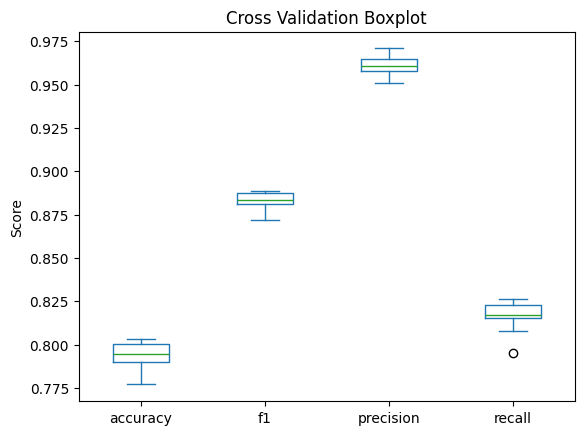

In [73]:
for metric_name in scoring_metrics:
    mean_score = cv_results_df[metric_name].mean()
    std_score = cv_results_df[metric_name].std()
    train_score = train_results[metric_name]

    print(f"{metric_name} - CV mean: {mean_score:.2f}, CV std: {std_score:.2f}")
    print(f"{metric_name} - Train score: {train_score:.2f}")

# Create a boxplot for the cross-validation results of each metric
cv_results_df.plot.box(title="Cross Validation Boxplot", ylabel="Score");

Conjunto de entrenamiento vs evaluación

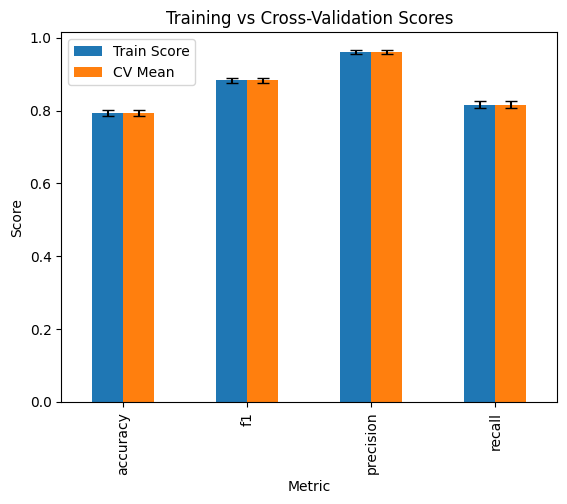

In [74]:
metrics_df = pd.DataFrame(
    {
        "Metric": scoring_metrics,
        "Train Score": [train_results[metric] for metric in scoring_metrics],
        "CV Mean": [cv_results_df[metric].mean() for metric in scoring_metrics],
        "CV Std": [cv_results_df[metric].std() for metric in scoring_metrics],
    }
)

# Create a bar plot for the training and cross-validation metrics
metrics_df.plot(
    kind="bar",
    x="Metric",
    y=["Train Score", "CV Mean"],
    yerr="CV Std",
    title="Training vs Cross-Validation Scores",
    ylabel="Score",
    capsize=4,
);

Matriz de confusión

In [75]:
model_pipe.fit(x_train, y_train)
y_pred = model_pipe.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.10      0.38      0.15       128
           1       0.96      0.82      0.89      2563

    accuracy                           0.80      2691
   macro avg       0.53      0.60      0.52      2691
weighted avg       0.92      0.80      0.85      2691



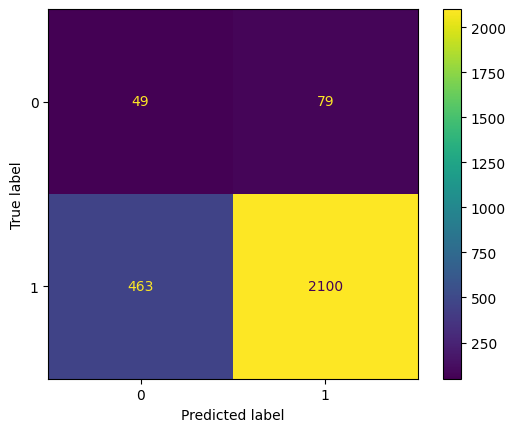

In [76]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

Consistencia del modelo

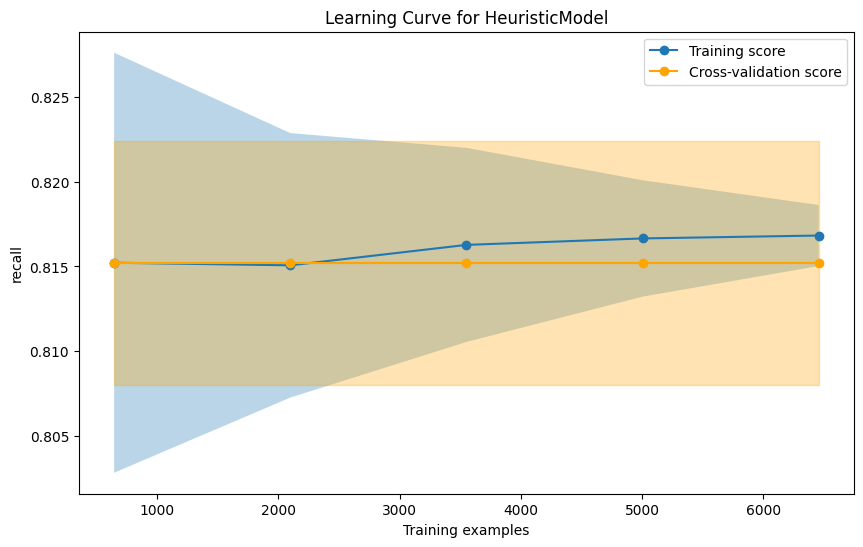

Training Sizes: [ 645 2098 3551 5004 6457]
Training Scores Mean: [0.81521659 0.81506266 0.81626966 0.81665057 0.81682233]
Training Scores Std: [0.01239911 0.00780964 0.00573085 0.00343624 0.0018021 ]
Test Scores Mean: [0.81517778 0.81517778 0.81517778 0.81517778 0.81517778]
Test Scores Std: [0.00720045 0.00720045 0.00720045 0.00720045 0.00720045]


In [77]:
common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "recall"

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    model_pipe, **common_params, scoring=scoring_metric
)

# Calculate the mean and standard deviation of the scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Calculate the mean and standard deviation of the fit and score times
fit_times_mean = np.mean(fit_times, axis=1)
fit_times_std = np.std(fit_times, axis=1)
score_times_mean = np.mean(score_times, axis=1)
score_times_std = np.std(score_times, axis=1)

# Plot the learning curve
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharey=True)
ax.plot(train_sizes, train_mean, "o-", label="Training score")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange"
)

# Configure the title and labels
ax.set_title(f"Learning Curve for {model.__class__.__name__}")
ax.set_xlabel("Training examples")
ax.set_ylabel(scoring_metric)
ax.legend(loc="best")

# Show the plot
plt.show()

# Print the values for analysis
print("Training Sizes:", train_sizes)
print("Training Scores Mean:", train_mean)
print("Training Scores Std:", train_std)
print("Test Scores Mean:", test_mean)
print("Test Scores Std:", test_std)

Escalabilidad

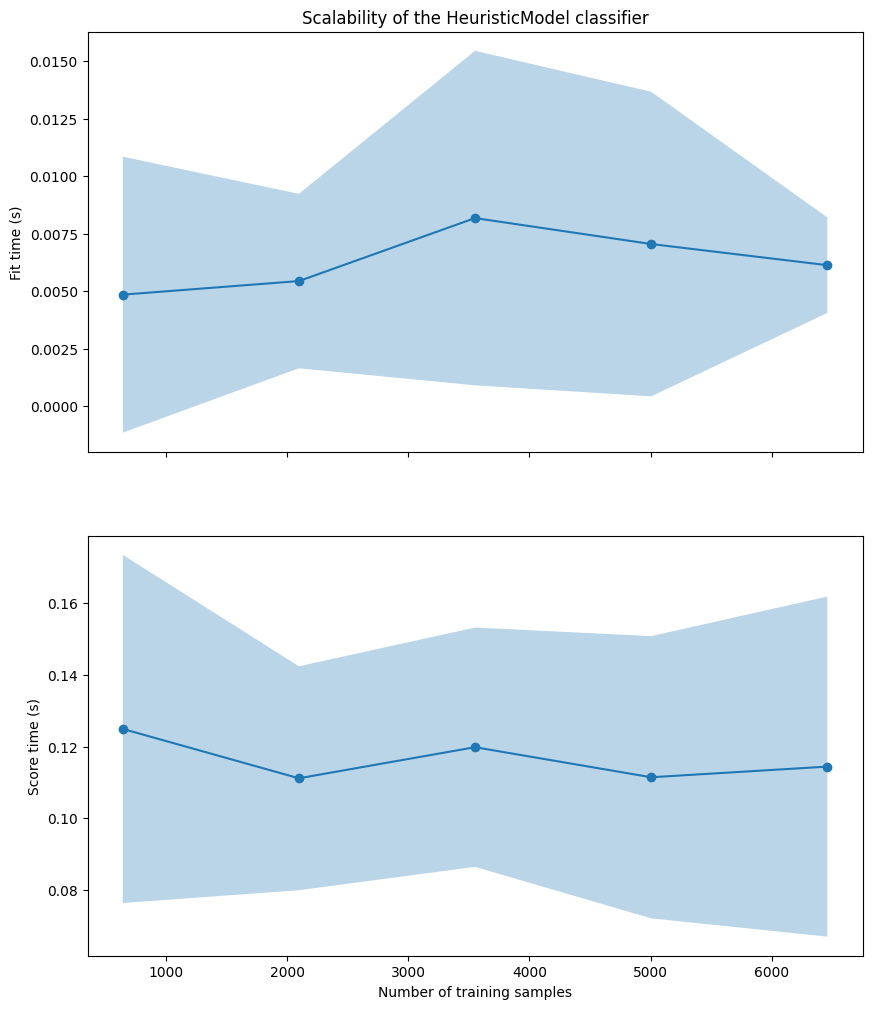

Fit Times Mean: [0.0048555  0.00544605 0.00818457 0.00705647 0.00613723]
Fit Times Std: [0.00599892 0.00379228 0.00727224 0.00662095 0.00207781]
Score Times Mean: [0.12490838 0.11114863 0.11981235 0.11143435 0.11440475]
Score Times Std: [0.04854671 0.03122234 0.03336732 0.03934657 0.04741032]


In [78]:
# Plot the scalability regarding fit time and score time
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), sharex=True)

# Scalability regarding the fit time
ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title(f"Scalability of the {model.__class__.__name__} classifier")

# Scalability regarding the score time
ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Number of training samples")

# Show the plot
plt.show()

# Print the fit and score times for analysis
print("Fit Times Mean:", fit_times_mean)
print("Fit Times Std:", fit_times_std)
print("Score Times Mean:", score_times_mean)
print("Score Times Std:", score_times_std)